Importing Libraries


In [1]:
import numpy as np

In [2]:

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"e:\Desktop\Student mark Predictor Deployment (1)\Student mark Predictor Deployment\student_info.csv")
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [4]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [5]:
df.shape

(200, 2)

In [6]:
#Visualize the data to gain insights

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [8]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


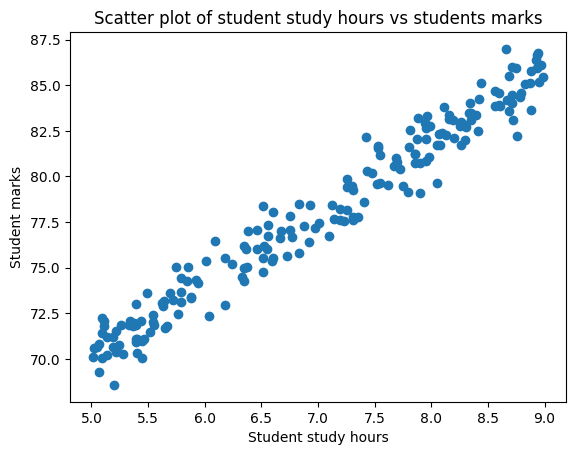

In [9]:
plt.scatter(x = df.study_hours, y = df.student_marks)
plt.xlabel('Student study hours')
plt.ylabel('Student marks')
plt.title('Scatter plot of student study hours vs students marks')
plt.show()

Prepare the data for MLA

In [10]:
# data cleaning
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [11]:
df.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [12]:
df2 = df.fillna(df.mean())
df2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [13]:
df2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


Split dataset

In [14]:
x = df2.drop('student_marks', axis = 'columns')
y = df2.drop('study_hours', axis = 'columns')
print('shape of x =',x.shape)
print('Shape of y =', y.shape)

shape of x = (200, 1)
Shape of y = (200, 1)


In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 51)
print("shape of x_train= ",x_train.shape)
print("shape of y_train= ", y_train.shape)
print("shape of x_test= ", x_test.shape)
print("shape of y_test = ", y_test.shape)

shape of x_train=  (160, 1)
shape of y_train=  (160, 1)
shape of x_test=  (40, 1)
shape of y_test =  (40, 1)


In [16]:
x_train

,study_hours
8,5.19
146,7.99
63,7.72
43,8.30
64,8.88
...,...
180,6.97
149,8.97
16,6.36
197,8.94


In [17]:
y_train

,student_marks
8,70.66
146,82.75
63,80.43
43,82.84
64,85.78
...,...
180,77.19
149,86.12
16,76.04
197,86.75


select model and train it

In [18]:
# y = mx + c
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [21]:
lr.coef_

array([[3.93571802]])

In [22]:
lr.intercept_

array([50.44735504])

In [23]:
m = 3.93
c =50.45
y = m*4 + c
print(y)

66.17


In [24]:
import warnings
warnings.filterwarnings('ignore')



In [25]:
lr.predict([[4]])[0][0].round(2)

np.float64(66.19)

In [26]:
y_pred = lr.predict(x_test)
y_pred

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [27]:
pd.DataFrame(np.c_[x_test, y_test, y_pred], columns=['Study_hours', 'Student_marks_original', 'student_marks_predicted'])

,Study_hours,Student_marks_original,student_marks_predicted
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


In [28]:
lr.score(x_test, y_test)

0.9514124242154464

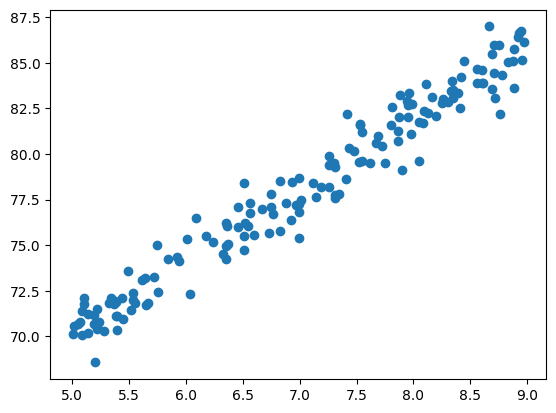

In [29]:
plt.scatter(x_train, y_train)

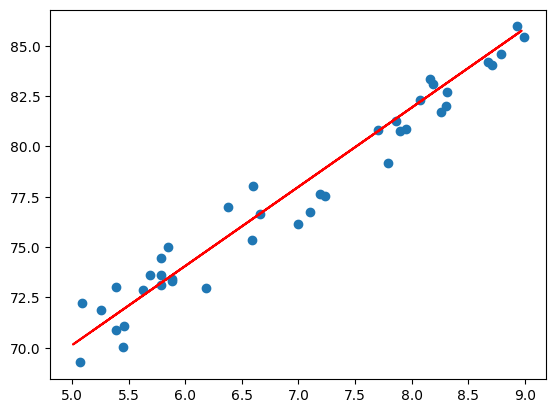

In [30]:
plt.scatter(x_test, y_test)
plt.plot(x_train, lr.predict(x_train), color = 'red')

In [33]:
#save MLModel

import joblib #create pipeline
joblib.dump(lr, 'Desktop.pkl')


['Desktop.pkl']

In [34]:
pwd

'c:\\Users\\LENOVO'

In [35]:
model = joblib.load("Desktop.pkl") #pickle


In [36]:
pwd


'c:\\Users\\LENOVO'